# 10. Modelo 1 – ARIMA

## 10.1. Construcción de las series de tiempo

El modelo ARIMA(p,d,q) se aplica sobre la serie de **lesiones no intencionales en West Virginia (1999–2017)**, la causa con mayor dinamismo identificada en la sección 9.

Se construyó la serie temporal a partir del dataset CDC filtrando West Virginia y la causa Unintentional injuries, excluyendo valores faltantes y ordenando cronológicamente.

In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("NCHS_Leading_Causes.csv", dtype=str)
df.columns = ['year','cause_113','cause_name','state','deaths','age_adjusted_death_rate']
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df['deaths'] = pd.to_numeric(df['deaths'].str.replace('.','',regex=False).str.replace(',','',regex=False), errors='coerce').fillna(0).astype(int)
df['age_adjusted_death_rate'] = pd.to_numeric(df['age_adjusted_death_rate'].str.replace(',','.'), errors='coerce')
df['state'] = df['state'].str.strip()
df['cause_name'] = df['cause_name'].str.strip()
df = df[(df['year']>=1999)&(df['year']<=2017)].dropna(subset=['year','age_adjusted_death_rate'])

estados = df[df['state']!='United States']
us = df[df['state']=='United States']
estados_2017 = estados[estados['year']==2017]
sin_all = estados[estados['cause_name']!='All causes']
print(f"Datos cargados: {len(df):,} filas | {df['state'].nunique()} entidades | {df['year'].min():.0f}–{df['year'].max():.0f}")

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import stats
import matplotlib.pyplot as plt
import io, base64

Datos cargados: 10,840 filas | 52 entidades | 1999–2017


In [2]:
wv_acc = (estados[(estados['state']=='West Virginia')&
                    (estados['cause_name']=='Unintentional injuries')]
           .sort_values('year')
           .dropna(subset=['age_adjusted_death_rate']))
serie = wv_acc.set_index('year')['age_adjusted_death_rate']
print("Serie West Virginia – Unintentional injuries (1999–2017):")
print(serie.round(2).to_string())
print(f"\nn = {len(serie)} observaciones")

Serie West Virginia – Unintentional injuries (1999–2017):
year
1999     42.0
2000     43.2
2001     44.7
2002     50.9
2003     53.7
2004     59.0
2005     49.6
2006     62.4
2007     65.8
2008     65.5
2009     48.2
2010     63.7
2011     74.8
2012     70.8
2013     71.7
2014     71.0
2015     77.9
2016     89.7
2017    100.3

n = 19 observaciones


## 10.2. Prueba de estacionariedad – Dickey-Fuller Aumentada (ADF)

In [3]:
adf = adfuller(serie)
print("=== Prueba ADF ===")
print(f"Estadístico ADF: {adf[0]:.4f}")
print(f"p-value:         {adf[1]:.4f}")
print(f"Lags utilizados: {adf[2]}")
print(f"Nobs:            {adf[3]}")
for k, v in adf[4].items():
    print(f"  Valor crítico {k}: {v:.4f}")
print(f"\nConclusión: La serie es {'estacionaria (p<0.05)' if adf[1]<0.05 else 'NO estacionaria (p≥0.05) → requiere diferenciación'}")

=== Prueba ADF ===
Estadístico ADF: 0.8801
p-value:         0.9928
Lags utilizados: 3
Nobs:            15
  Valor crítico 1%: -3.9644
  Valor crítico 5%: -3.0849
  Valor crítico 10%: -2.6818

Conclusión: La serie es NO estacionaria (p≥0.05) → requiere diferenciación


## 10.3. ACF y PACF – identificación visual del orden

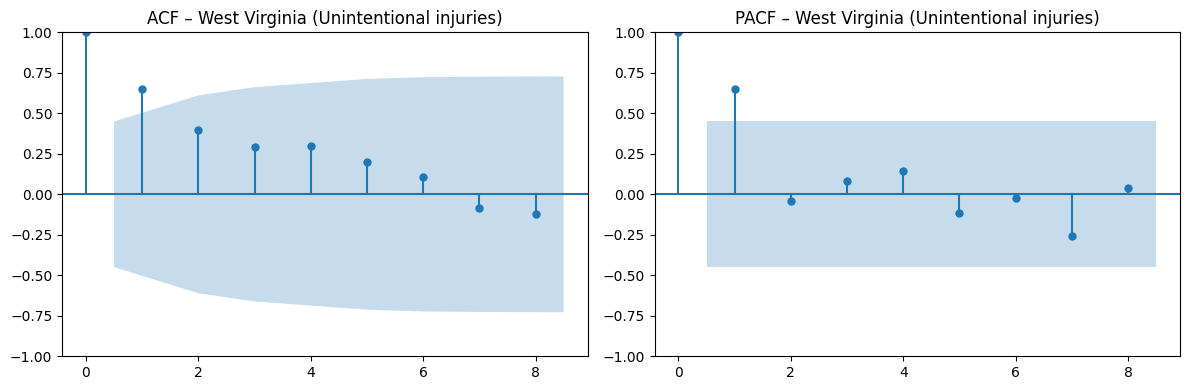

ACF/PACF generados con 8 lags


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
max_lags = len(serie) // 2 - 1
plot_acf(serie, ax=axes[0], lags=max_lags, title='ACF – West Virginia (Unintentional injuries)')
plot_pacf(serie, ax=axes[1], lags=max_lags, title='PACF – West Virginia (Unintentional injuries)')
plt.tight_layout()
plt.show()
print(f"ACF/PACF generados con {max_lags} lags")

## 10.4. Selección automática del modelo

In [5]:
from statsmodels.tsa.arima.model import ARIMA

mejor_aicc = np.inf
mejor_orden = None

for p in range(0,3):
    for d in range(0,2):
        for q in range(0,3):
            try:
                m = ARIMA(serie, order=(p,d,q)).fit()
                if m.aicc < mejor_aicc:
                    mejor_aicc = m.aicc
                    mejor_orden = (p,d,q)
                    mejor_modelo = m
            except: pass

print(f"Mejor orden ARIMA: {mejor_orden}")
print(f"AICc: {mejor_aicc:.2f}")
print(mejor_modelo.summary())

Mejor orden ARIMA: (0, 1, 0)
AICc: 130.66
                                  SARIMAX Results                                  
Dep. Variable:     age_adjusted_death_rate   No. Observations:                   19
Model:                      ARIMA(0, 1, 0)   Log Likelihood                 -64.204
Date:                     Sun, 24 May 2026   AIC                            130.408
Time:                             02:05:51   BIC                            131.298
Sample:                                  0   HQIC                           130.531
                                      - 19                                         
Covariance Type:                       opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2        73.4010     29.095      2.523      0.012      16.376     130.427
Ljung-Box (L1) (Q):                   0.55   Jarq

C:\Users\luisc\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\luisc\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## 10.5. Diagnóstico de residuos

In [6]:
residuos = mejor_modelo.resid
from statsmodels.stats.diagnostic import acorr_ljungbox
lb = acorr_ljungbox(residuos, lags=[4], return_df=True)
print("=== Diagnóstico de residuos ===")
print(f"Media residuos:   {residuos.mean():.4f}")
print(f"Ljung-Box Q*:     {lb['lb_stat'].values[0]:.4f}")
print(f"Ljung-Box p-val:  {lb['lb_pvalue'].values[0]:.4f}")
print(f"Conclusión: {'✔ Residuos independientes' if lb['lb_pvalue'].values[0]>0.05 else '⚠ Autocorrelación en residuos'}")

fig = go.Figure()
fig.add_trace(go.Scatter(x=list(range(len(residuos))), y=residuos.values,
                          mode='lines+markers', name='Residuos',
                          line=dict(color='#457B9D')))
fig.add_hline(y=0, line_dash='dash', line_color='gray')
fig.update_layout(title='Residuos del Modelo ARIMA', xaxis_title='Tiempo',
                   yaxis_title='Residuo', height=350, template='plotly_white')
fig.show()

=== Diagnóstico de residuos ===
Media residuos:   5.2789
Ljung-Box Q*:     1.3133
Ljung-Box p-val:  0.8591
Conclusión: ✔ Residuos independientes


## 10.6. Proyecciones ARIMA – West Virginia (2018–2022)

In [7]:
forecast = mejor_modelo.get_forecast(steps=5)
fv = forecast.predicted_mean
ci = forecast.conf_int()
anios_fut = list(range(2018, 2023))

fig = go.Figure()
fig.add_trace(go.Scatter(x=list(serie.index)+list(anios_fut),
                          y=list(serie.values)+[None]*5,
                          mode='lines+markers', name='Observado',
                          line=dict(color='#1D3557', width=2),
                          marker=dict(size=6)))
fig.add_trace(go.Scatter(
    x=list(ci.index)+list(ci.index[::-1]),
    y=list(ci.iloc[:,0])+list(ci.iloc[:,1][::-1]),
    fill='toself', fillcolor='rgba(230,57,70,0.15)',
    line=dict(color='rgba(0,0,0,0)'), name='IC 95%'))
fig.add_trace(go.Scatter(x=anios_fut, y=fv.values, mode='lines+markers',
                          name='Proyección ARIMA',
                          line=dict(color='#E63946', width=2, dash='dash'),
                          marker=dict(size=8, symbol='triangle-up')))
fig.add_vline(x=2017.5, line_dash='dot', line_color='gray')
fig.update_layout(title='Proyecciones ARIMA – Unintentional Injuries · West Virginia (2018–2022)',
                   xaxis_title='Año', yaxis_title='Tasa por 100,000 hab.',
                   height=460, template='plotly_white',
                   xaxis=dict(tickmode='linear', tick0=1999, dtick=2))
fig.show()

## 10.7. Tabla de valores proyectados

In [8]:
tabla_arima = pd.DataFrame({
    'Año': anios_fut,
    'Predicción': fv.values.round(1),
    'IC 95% inf.': ci.iloc[:,0].values.round(1),
    'IC 95% sup.': ci.iloc[:,1].values.round(1)
})
print(tabla_arima.to_string(index=False))

 Año  Predicción  IC 95% inf.  IC 95% sup.
2018       100.3         83.5        117.1
2019       100.3         76.6        124.0
2020       100.3         71.2        129.4
2021       100.3         66.7        133.9
2022       100.3         62.8        137.8
